In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

traffic_df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
traffic_df = pd.DataFrame(traffic_df)

traffic_df['date_time'] = pd.to_datetime(traffic_df['date_time'], format='%d-%m-%Y %H:%M')
traffic_df = traffic_df.sort_values('date_time').reset_index(drop=True)

traffic_df['isHoliday'] = pd.notna(traffic_df['holiday']).astype('int')
traffic_df['hour']=traffic_df['date_time'].dt.hour
traffic_df['dayOfWeek']=traffic_df['date_time'].dt.weekday
traffic_df['month'] = traffic_df['date_time'].dt.month
traffic_df['isWeekend'] = (traffic_df['date_time'].dt.weekday >= 5).astype(int)
traffic_df['hour_sin'] = np.sin(2 * np.pi * traffic_df['hour'] / 24.0)
traffic_df['hour_cos'] = np.cos(2 * np.pi * traffic_df['hour'] / 24.0)

features_test1 = ['dayOfWeek', 'month', 'hour_sin', 'hour_cos', 'isHoliday']
X1 = traffic_df[features_test1]

num_features_test2 = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'dayOfWeek', 'month', 'hour_sin', 'hour_cos', 'isHoliday']
cat_features_test2 = ['weather_main']
X2 = traffic_df[num_features_test2+cat_features_test2]
preprocessor_test2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features_test2),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features_test2)
    ])

y = traffic_df['traffic_volume'].values



## Relevant dates for weather events
Heavy snow : 23-12-2015

Heavy rain : 11-07-2016

Rain : 19-12-2013

Fog : 14-10-2012


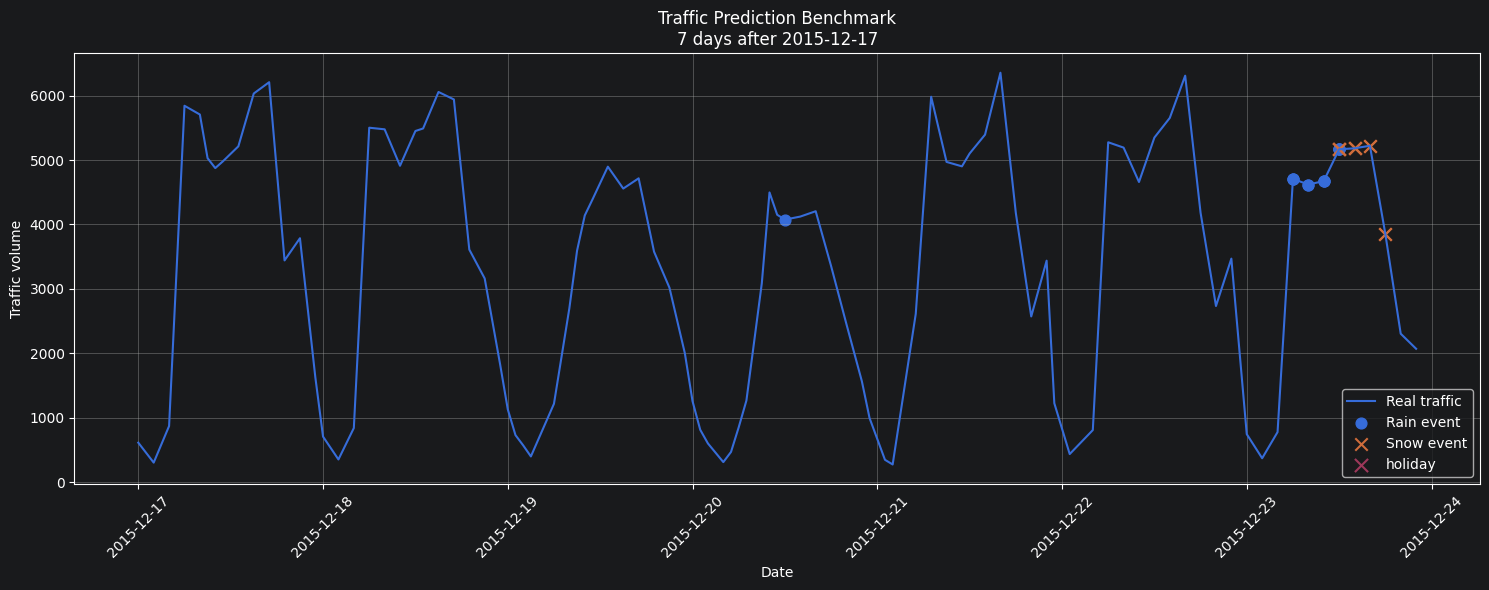

In [2]:


chosen_date = '2015-12-17'   # <- CHANGE THIS
# ---------------------------------------------------------
# Extract 7 days after chosen date
# ---------------------------------------------------------
start_date = pd.to_datetime(chosen_date)
end_date = start_date + pd.Timedelta(days=7)

mask = (
    (traffic_df['date_time'] >= start_date) &
    (traffic_df['date_time'] < end_date)
)

dates_period = traffic_df.loc[mask, 'date_time']
y_real_period = traffic_df.loc[mask, 'traffic_volume']

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(15,6))

plt.plot(
    dates_period,
    y_real_period,
    label='Real traffic'
)
# ---------------------------------------------------------
# Highlight special weather events
# ---------------------------------------------------------

rain_mask = traffic_df.loc[mask, 'rain_1h'] > 0
snow_mask = traffic_df.loc[mask, 'snow_1h'] > 0
holiday_mask = traffic_df.loc[mask, 'isHoliday'] > 0

plt.scatter(
    dates_period[rain_mask],
    y_real_period[rain_mask],
    marker='o',
    s=60,
    label='Rain event'
)

plt.scatter(
    dates_period[snow_mask],
    y_real_period[snow_mask],
    marker='x',
    s=80,
    label='Snow event'
)
plt.scatter(
    dates_period[holiday_mask],
    y_real_period[holiday_mask],
    marker='x',
    s=90,
    label='holiday'
)

# ---------------------------------------------------------
# Cosmetics
# ---------------------------------------------------------

plt.xlabel('Date')
plt.ylabel('Traffic volume')

plt.title(
    f'Traffic Prediction Benchmark\n'
    f'7 days after {chosen_date}'
)

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

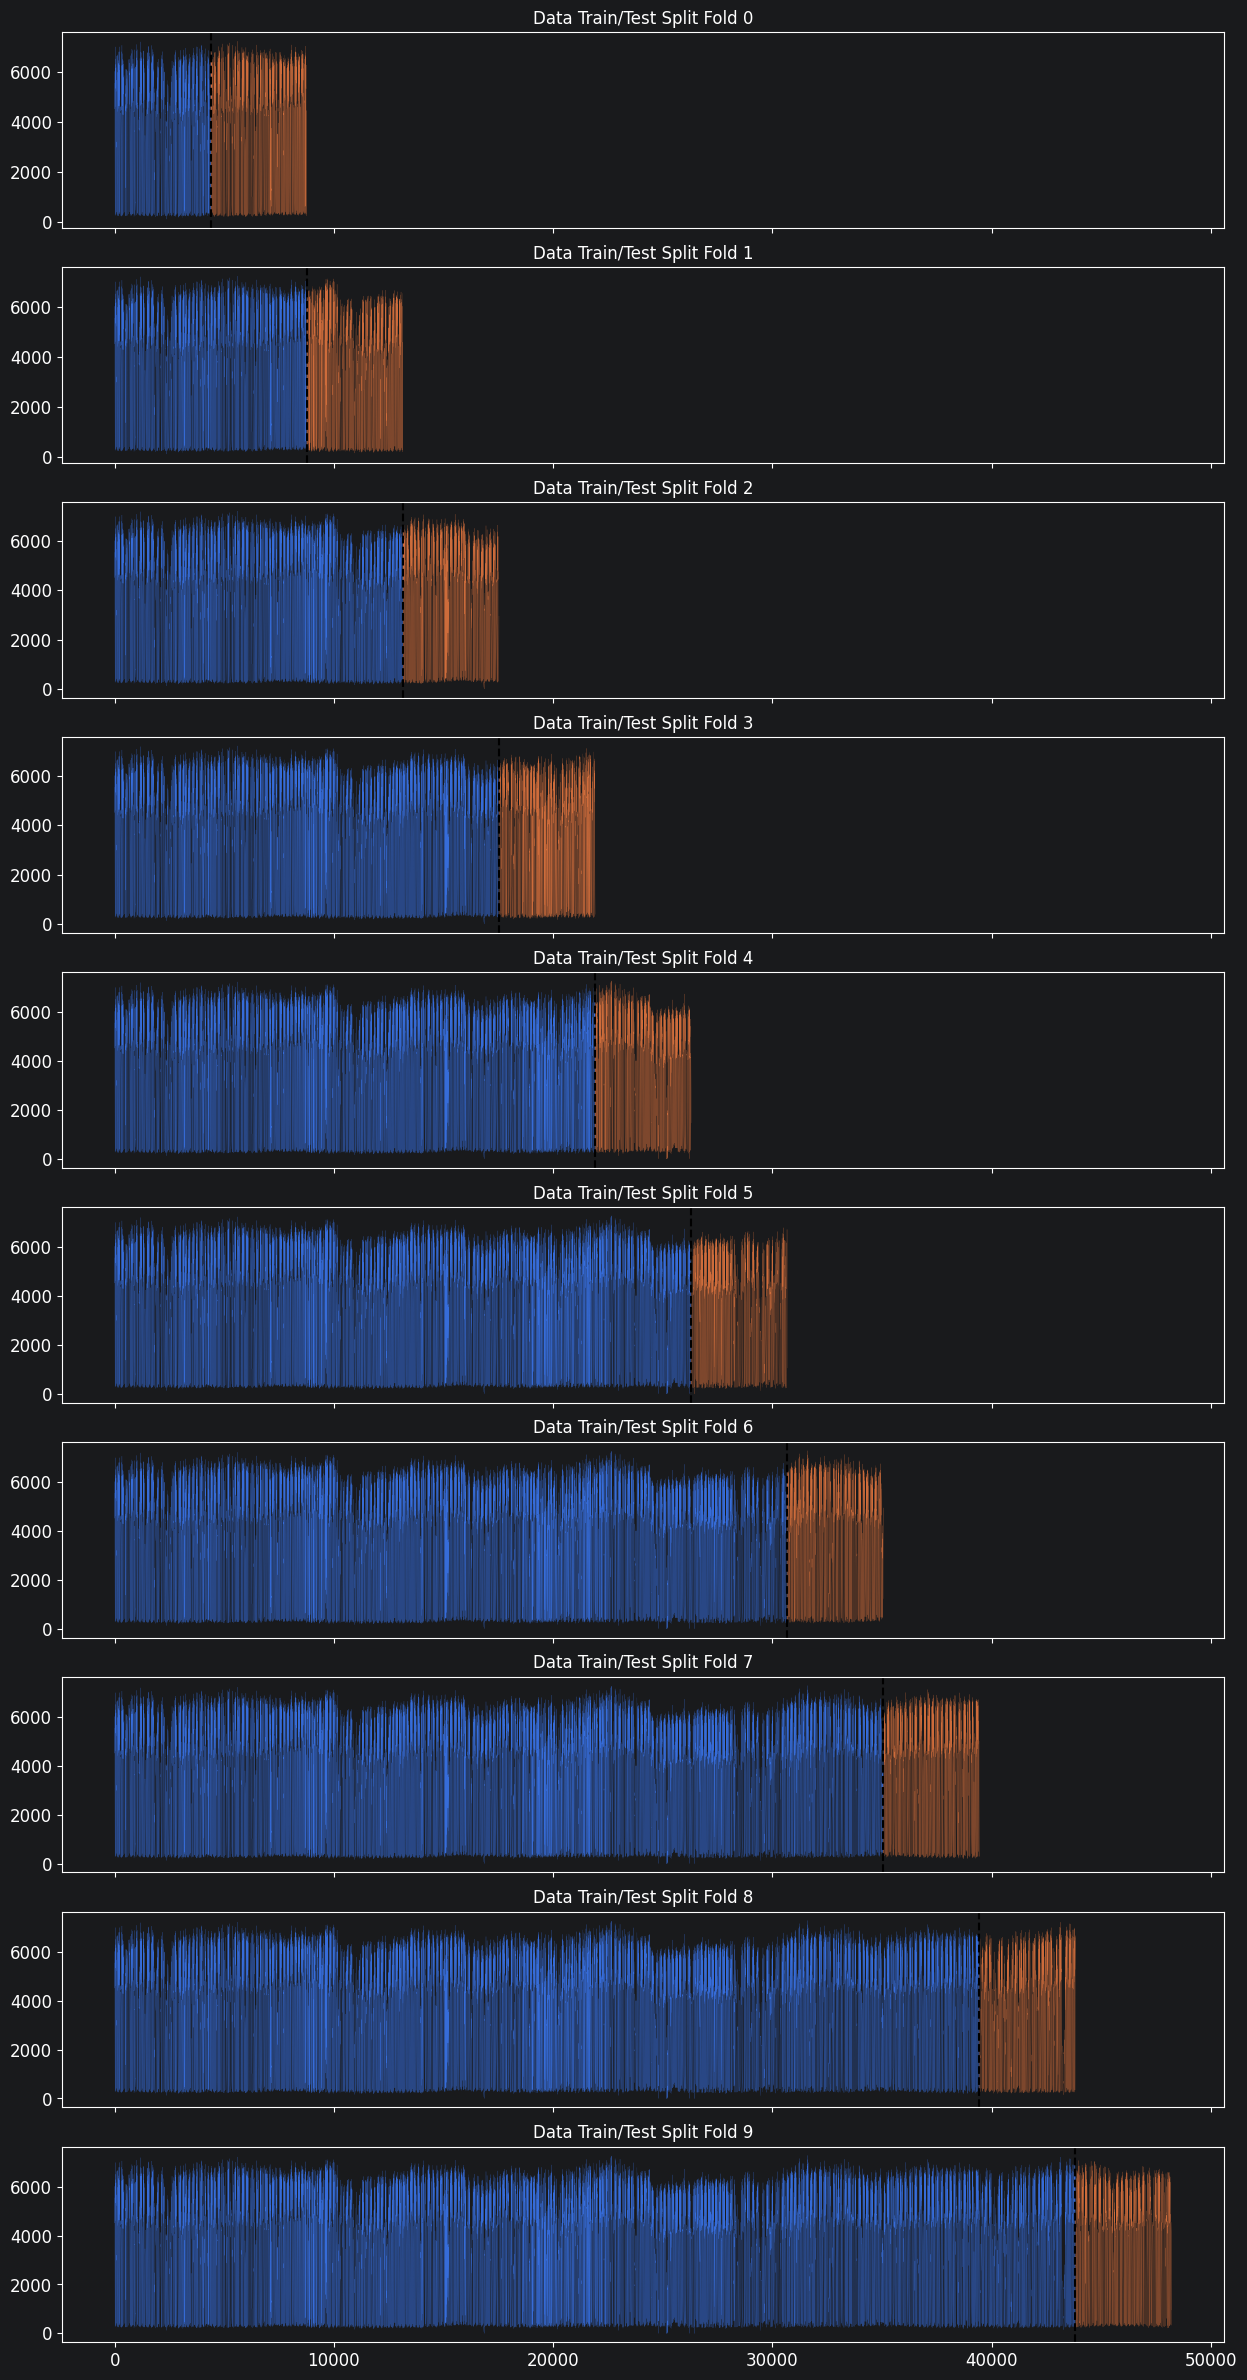

In [3]:
tss = TimeSeriesSplit(n_splits = 10, gap = 0)
#traffic_df.set_index('date_time',inplace=True)

fig, axs = plt.subplots(10, 1, figsize = (15, 30), sharex = True)
fold = 0

for train_idx, val_idx in tss.split(traffic_df):

    train = traffic_df.iloc[train_idx]
    test = traffic_df.iloc[val_idx]

    train['traffic_volume'].plot(ax = axs[fold],
                                 label = 'Training Set',
                                 title = f'Data Train/Test Split Fold {fold}',
                                 fontsize = 12,
                                 linewidth = 0.1)

    test['traffic_volume'].plot(ax = axs[fold],
                                label = 'Test Set',
                                linewidth = 0.1)

    axs[fold].axvline(test.index.min(),
                      color = 'black',
                      ls = '--')
    fold += 1

plt.show()

R2: 0.6777782679049094
RMSE: 1173.7436551976618
                           feature  coefficient     abs_coef
7                    num__hour_cos -1456.358774  1456.358774
6                    num__hour_sin  -451.849190   451.849190
4                   num__dayOfWeek  -267.969076   267.969076
0                        num__temp    32.736002    32.736002
1                     num__rain_1h     0.000000     0.000000
2                     num__snow_1h     0.000000     0.000000
5                       num__month    -0.000000     0.000000
3                  num__clouds_all    -0.000000     0.000000
8                   num__isHoliday    -0.000000     0.000000
9          cat__weather_main_Clear     0.000000     0.000000
10        cat__weather_main_Clouds     0.000000     0.000000
11       cat__weather_main_Drizzle    -0.000000     0.000000
12           cat__weather_main_Fog    -0.000000     0.000000
13          cat__weather_main_Haze    -0.000000     0.000000
14          cat__weather_main_Mist   

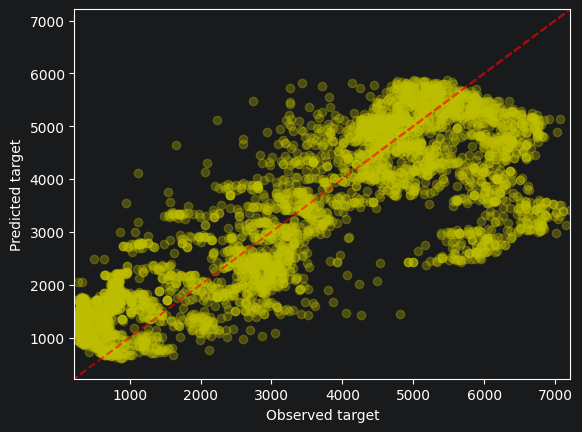

R2: 0.6725552945278196
RMSE: 1120.8789742497727
                           feature  coefficient     abs_coef
7                    num__hour_cos -1532.826876  1532.826876
6                    num__hour_sin  -485.310744   485.310744
4                   num__dayOfWeek  -331.349817   331.349817
0                        num__temp   106.994464   106.994464
5                       num__month   -29.716849    29.716849
1                     num__rain_1h   -13.497145    13.497145
8                   num__isHoliday    -5.526614     5.526614
2                     num__snow_1h     0.000000     0.000000
3                  num__clouds_all    -0.000000     0.000000
9          cat__weather_main_Clear     0.000000     0.000000
10        cat__weather_main_Clouds     0.000000     0.000000
11       cat__weather_main_Drizzle     0.000000     0.000000
12           cat__weather_main_Fog     0.000000     0.000000
13          cat__weather_main_Haze    -0.000000     0.000000
14          cat__weather_main_Mist   

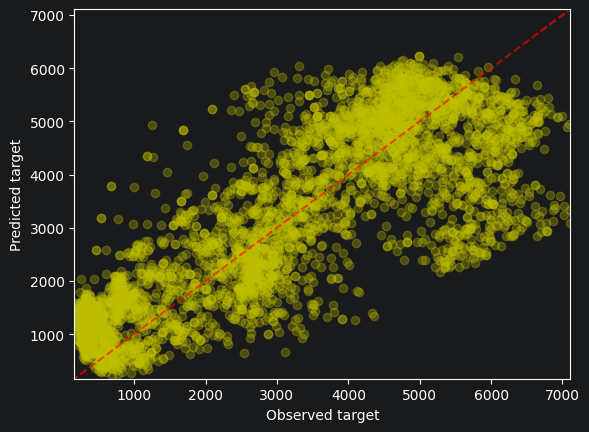

R2: 0.6860271935476747
RMSE: 1119.4663697642159
                           feature  coefficient     abs_coef
7                    num__hour_cos -1522.994891  1522.994891
6                    num__hour_sin  -495.464310   495.464310
4                   num__dayOfWeek  -310.832589   310.832589
16          cat__weather_main_Snow  -168.165870   168.165870
0                        num__temp   135.620375   135.620375
13          cat__weather_main_Haze  -112.795489   112.795489
1                     num__rain_1h   -22.202342    22.202342
8                   num__isHoliday   -17.780469    17.780469
5                       num__month   -16.973784    16.973784
3                  num__clouds_all   -13.414130    13.414130
2                     num__snow_1h     0.000000     0.000000
10        cat__weather_main_Clouds     0.000000     0.000000
9          cat__weather_main_Clear     0.000000     0.000000
12           cat__weather_main_Fog     0.000000     0.000000
11       cat__weather_main_Drizzle   

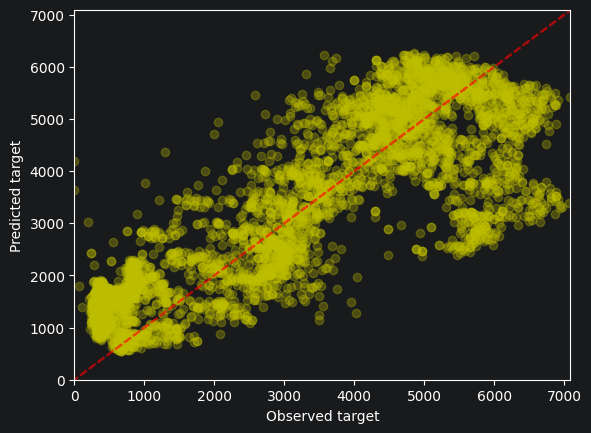

R2: 0.6820546984481
RMSE: 1145.5214901321951
                           feature  coefficient     abs_coef
7                    num__hour_cos -1522.834935  1522.834935
6                    num__hour_sin  -501.888769   501.888769
4                   num__dayOfWeek  -322.672494   322.672494
17          cat__weather_main_Snow  -165.415623   165.415623
13          cat__weather_main_Haze  -141.651539   141.651539
0                        num__temp   112.050047   112.050047
1                     num__rain_1h   -29.260730    29.260730
3                  num__clouds_all   -18.196480    18.196480
8                   num__isHoliday   -16.457134    16.457134
5                       num__month   -15.105589    15.105589
10        cat__weather_main_Clouds    10.896468    10.896468
2                     num__snow_1h     0.000000     0.000000
11       cat__weather_main_Drizzle     0.000000     0.000000
9          cat__weather_main_Clear    -0.000000     0.000000
14          cat__weather_main_Mist     0

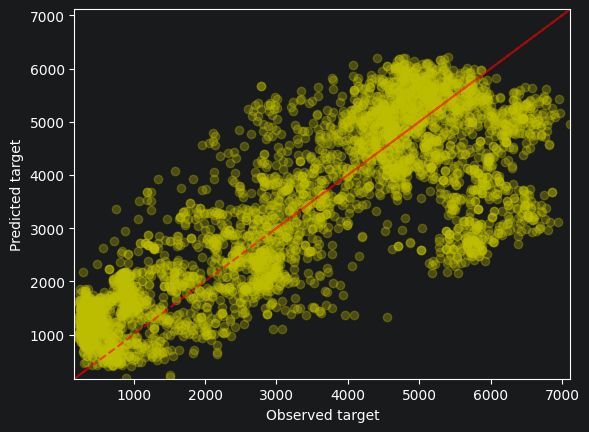

R2: -1.9277870259276306
RMSE: 3369.227083570653
                           feature  coefficient     abs_coef
7                    num__hour_cos -1533.343370  1533.343370
6                    num__hour_sin  -493.469119   493.469119
4                   num__dayOfWeek  -321.712382   321.712382
17          cat__weather_main_Snow  -161.593007   161.593007
13          cat__weather_main_Haze  -150.978428   150.978428
0                        num__temp   108.351558   108.351558
5                       num__month   -28.949778    28.949778
1                     num__rain_1h   -27.213353    27.213353
9          cat__weather_main_Clear   -20.769979    20.769979
14          cat__weather_main_Mist    19.267392    19.267392
8                   num__isHoliday   -14.961488    14.961488
3                  num__clouds_all   -14.526431    14.526431
2                     num__snow_1h   -11.711125    11.711125
10        cat__weather_main_Clouds     0.936585     0.936585
11       cat__weather_main_Drizzle   

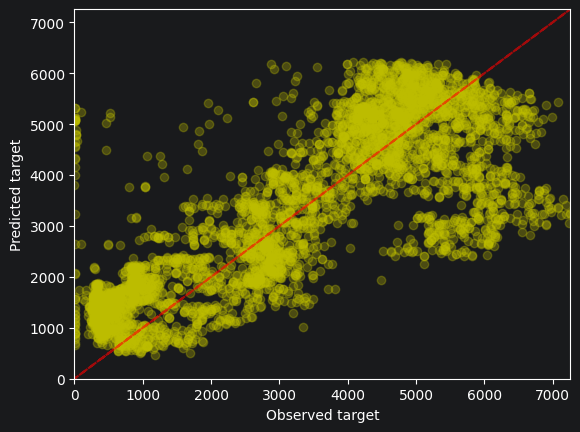

R2: 0.658268376464556
RMSE: 1097.0528634414477
                           feature  coefficient     abs_coef
7                    num__hour_cos -1525.166170  1525.166170
6                    num__hour_sin  -485.377995   485.377995
4                   num__dayOfWeek  -320.893504   320.893504
17          cat__weather_main_Snow  -133.473342   133.473342
13          cat__weather_main_Haze   -92.652098    92.652098
0                        num__temp    76.434465    76.434465
19  cat__weather_main_Thunderstorm   -47.652979    47.652979
14          cat__weather_main_Mist    37.677033    37.677033
5                       num__month   -31.869247    31.869247
11       cat__weather_main_Drizzle    27.011729    27.011729
3                  num__clouds_all   -16.085408    16.085408
8                   num__isHoliday   -14.724575    14.724575
10        cat__weather_main_Clouds    13.795543    13.795543
2                     num__snow_1h   -10.532961    10.532961
9          cat__weather_main_Clear    

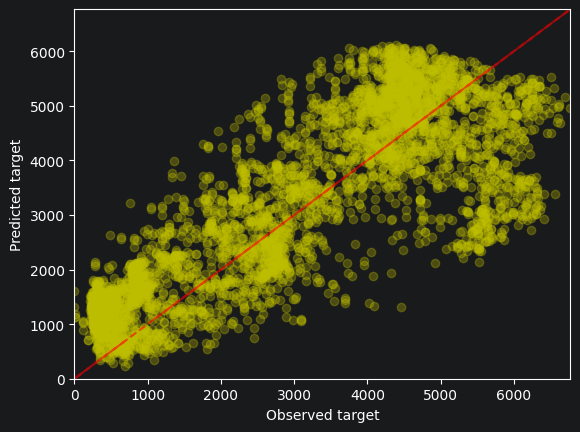

R2: 0.6726454604697454
RMSE: 1137.4881332185896
                           feature  coefficient     abs_coef
7                    num__hour_cos -1512.738292  1512.738292
6                    num__hour_sin  -472.506487   472.506487
4                   num__dayOfWeek  -310.964926   310.964926
17          cat__weather_main_Snow  -138.820876   138.820876
13          cat__weather_main_Haze  -122.092571   122.092571
0                        num__temp    77.298588    77.298588
10        cat__weather_main_Clouds    49.043016    49.043016
5                       num__month   -41.822889    41.822889
11       cat__weather_main_Drizzle    33.947602    33.947602
19  cat__weather_main_Thunderstorm   -30.156231    30.156231
3                  num__clouds_all   -29.025415    29.025415
8                   num__isHoliday   -16.890264    16.890264
2                     num__snow_1h    -6.976158     6.976158
9          cat__weather_main_Clear    -5.853857     5.853857
15          cat__weather_main_Rain   

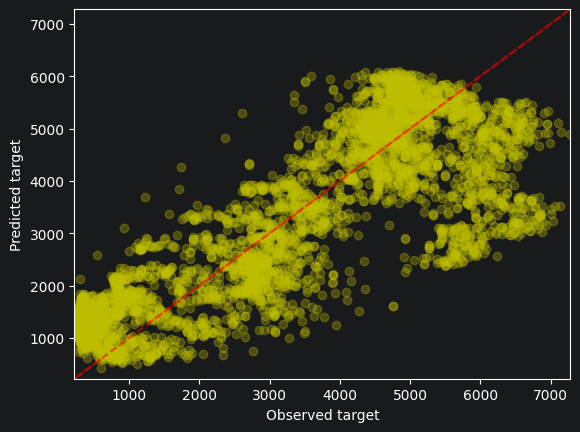

R2: 0.6688275359994145
RMSE: 1164.9052202845237
                           feature  coefficient     abs_coef
7                    num__hour_cos -1515.826862  1515.826862
6                    num__hour_sin  -476.767573   476.767573
4                   num__dayOfWeek  -306.894406   306.894406
17          cat__weather_main_Snow  -135.918886   135.918886
13          cat__weather_main_Haze  -126.056227   126.056227
0                        num__temp    70.226542    70.226542
5                       num__month   -52.249543    52.249543
19  cat__weather_main_Thunderstorm   -47.438902    47.438902
10        cat__weather_main_Clouds    34.378185    34.378185
3                  num__clouds_all   -31.580719    31.580719
8                   num__isHoliday   -16.479489    16.479489
11       cat__weather_main_Drizzle     8.491663     8.491663
2                     num__snow_1h    -6.815312     6.815312
9          cat__weather_main_Clear    -3.386574     3.386574
1                     num__rain_1h   

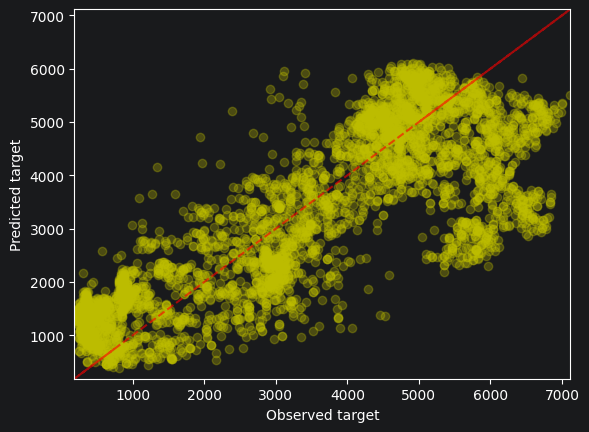

R2: 0.6478779456553515
RMSE: 1165.2717897570626
                           feature  coefficient     abs_coef
7                    num__hour_cos -1521.042909  1521.042909
6                    num__hour_sin  -480.773860   480.773860
4                   num__dayOfWeek  -302.198021   302.198021
17          cat__weather_main_Snow  -138.006322   138.006322
13          cat__weather_main_Haze  -118.295504   118.295504
0                        num__temp    67.201885    67.201885
12           cat__weather_main_Fog    36.874346    36.874346
5                       num__month   -34.619269    34.619269
3                  num__clouds_all   -26.890212    26.890212
11       cat__weather_main_Drizzle    24.039832    24.039832
10        cat__weather_main_Clouds    20.083285    20.083285
19  cat__weather_main_Thunderstorm   -18.221526    18.221526
8                   num__isHoliday   -16.311065    16.311065
9          cat__weather_main_Clear   -10.664253    10.664253
2                     num__snow_1h   

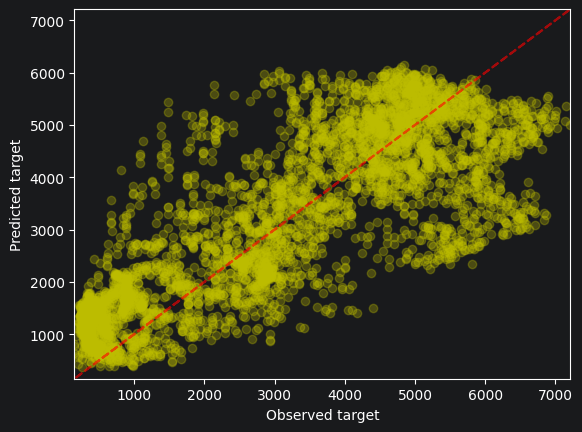

R2: 0.6669037351082314
RMSE: 1127.9102682300222
                           feature  coefficient     abs_coef
7                    num__hour_cos -1515.865627  1515.865627
6                    num__hour_sin  -477.205169   477.205169
4                   num__dayOfWeek  -296.077685   296.077685
17          cat__weather_main_Snow  -141.449527   141.449527
13          cat__weather_main_Haze  -109.596058   109.596058
0                        num__temp    75.674701    75.674701
10        cat__weather_main_Clouds    62.428153    62.428153
11       cat__weather_main_Drizzle    45.590663    45.590663
3                  num__clouds_all   -45.049798    45.049798
5                       num__month   -29.328081    29.328081
8                   num__isHoliday   -16.745175    16.745175
15          cat__weather_main_Rain    13.195781    13.195781
9          cat__weather_main_Clear    -6.432948     6.432948
2                     num__snow_1h    -5.776683     5.776683
14          cat__weather_main_Mist   

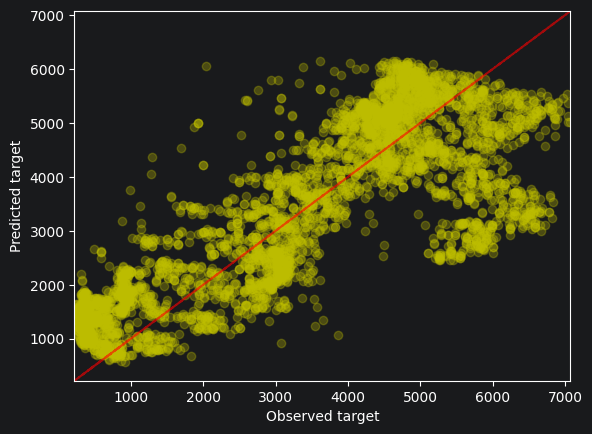

In [4]:
from sklearn.linear_model import LassoCV
tss = TimeSeriesSplit(n_splits = 10, gap = 0)
for train_index, test_index in tss.split(traffic_df):
    # Split data sequentially
    X_tr, X_te = X2.iloc[train_index], X2.iloc[test_index]
    y_tr, y_te = y[train_index], y[test_index]

    X_tr = preprocessor_test2.fit_transform(X_tr)
    X_te = preprocessor_test2.transform(X_te)

    LassoCV_reg = LassoCV(cv=5, random_state=42).fit(X_tr, y_tr) # Bizarre qu'il faille mettre une tol aussi basse...
    y_pred_lassoCV = LassoCV_reg.predict(X_te)

    print("R2:", r2_score(y_te, y_pred_lassoCV))
    print("RMSE:", np.sqrt(mean_squared_error(y_te, y_pred_lassoCV)))

    feature_names = preprocessor_test2.get_feature_names_out()
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': LassoCV_reg.coef_
    })
    coef_df['abs_coef'] = np.abs(coef_df['coefficient'])
    print(coef_df.sort_values('abs_coef', ascending=False))

    plt.scatter(y_te, y_pred_lassoCV, c='y', alpha = 0.3)
    plt.plot(y_te, y_te, c='r', alpha=0.6, ls='--')
    plt.xlim(y_te.min()-1, y_te.max()+1)
    plt.ylim(y_te.min()-1, y_te.max()+1)
    plt.xlabel('Observed target')
    plt.ylabel('Predicted target')
    plt.show()

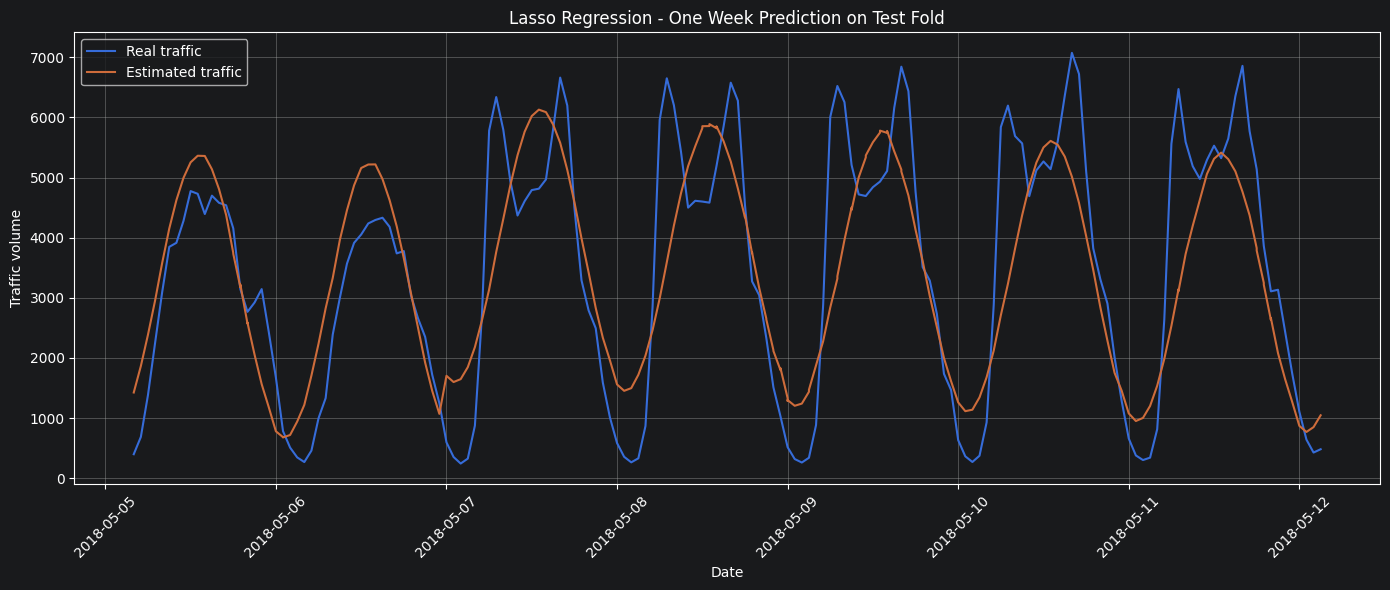

In [5]:
dates_test = traffic_df.iloc[test_index]['date_time'].reset_index(drop=True)

# first week of the fold
start_date = dates_test.iloc[0]
end_date = start_date + pd.Timedelta(days=7)

week_mask = (dates_test >= start_date) & (dates_test < end_date)

dates_week = dates_test[week_mask]

y_real_week = y_te[week_mask]
y_pred_week = y_pred_lassoCV[week_mask]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(dates_week, y_real_week, label='Real traffic')
plt.plot(dates_week, y_pred_week, label='Estimated traffic')

plt.xlabel('Date')
plt.ylabel('Traffic volume')
plt.title('Lasso Regression - One Week Prediction on Test Fold')

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

R2: 0.9564502370253646
RMSE: 407.8331904271611


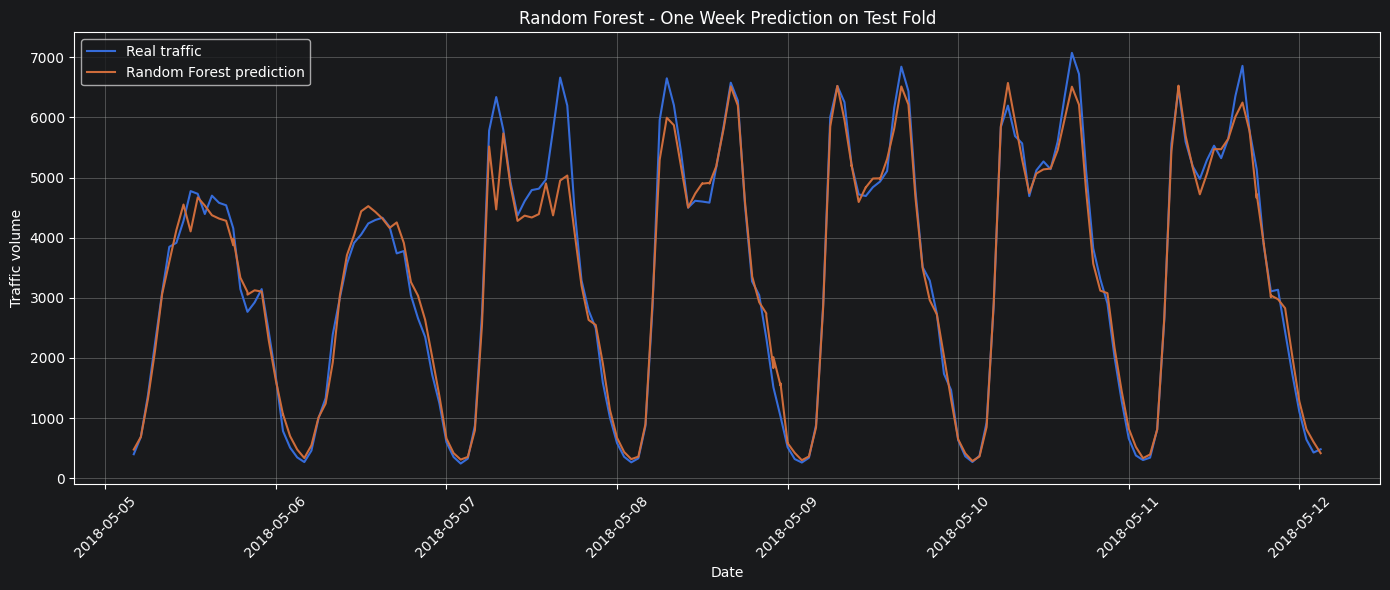

                           feature  importance
18             remainder__hour_cos    0.664616
17             remainder__hour_sin    0.175069
15            remainder__dayOfWeek    0.110673
11                 remainder__temp    0.028036
16                remainder__month    0.008653
14           remainder__clouds_all    0.005038
12              remainder__rain_1h    0.002500
1         cat__weather_main_Clouds    0.001474
3            cat__weather_main_Fog    0.000736
5           cat__weather_main_Mist    0.000718
8           cat__weather_main_Snow    0.000644
0          cat__weather_main_Clear    0.000588
4           cat__weather_main_Haze    0.000458
6           cat__weather_main_Rain    0.000318
10  cat__weather_main_Thunderstorm    0.000179


In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

# ---------------------------------------------------------
# Time series split
# ---------------------------------------------------------

tss = TimeSeriesSplit(n_splits=10)

# Take ONLY the last fold
for train_index, test_index in tss.split(X2):
    pass

X_tr, X_te = X2.iloc[train_index], X2.iloc[test_index]
y_tr, y_te = y[train_index], y[test_index]

# ---------------------------------------------------------
# Preprocessing
# ---------------------------------------------------------
# Random Forest does NOT require scaling,
# but we still need one-hot encoding.

preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_test2)
    ],
    remainder='passthrough'
)

X_tr = preprocessor_rf.fit_transform(X_tr)
X_te = preprocessor_rf.transform(X_te)

# ---------------------------------------------------------
# Train Random Forest
# ---------------------------------------------------------

RF_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

RF_reg.fit(X_tr, y_tr)

# ---------------------------------------------------------
# Predictions
# ---------------------------------------------------------

y_pred = RF_reg.predict(X_te)

print("R2:", r2_score(y_te, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_te, y_pred)))

# ---------------------------------------------------------
# Select ONE WEEK from the test fold
# ---------------------------------------------------------

dates_test = traffic_df.iloc[test_index]['date_time'].reset_index(drop=True)

start_date = dates_test.iloc[0]
end_date = start_date + pd.Timedelta(days=7)

week_mask = (dates_test >= start_date) & (dates_test < end_date)

dates_week = dates_test[week_mask]

y_real_week = y_te[week_mask]
y_pred_week = y_pred[week_mask]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(dates_week, y_real_week, label='Real traffic')
plt.plot(dates_week, y_pred_week, label='Random Forest prediction')

plt.xlabel('Date')
plt.ylabel('Traffic volume')
plt.title('Random Forest - One Week Prediction on Test Fold')

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Feature importance
# ---------------------------------------------------------

feature_names = preprocessor_rf.get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': RF_reg.feature_importances_
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

print(importance_df.head(15))